In [4]:
import json
from pathlib import Path
from typing import Dict, List

from model_ranking import (
    plot_alpha_sweep_specific_norm,
    plot_performance_vs_transfer_metric_multi_target,
    to_target_transfer_correlations,
    correlation_table,
    load_transfer_metric_results,
)

In [5]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_Gauss_a001-a003__AllLayers_CMB_05f_05b_consistency_scores.json
Processing: Gauss_Consistency_a001-a003
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


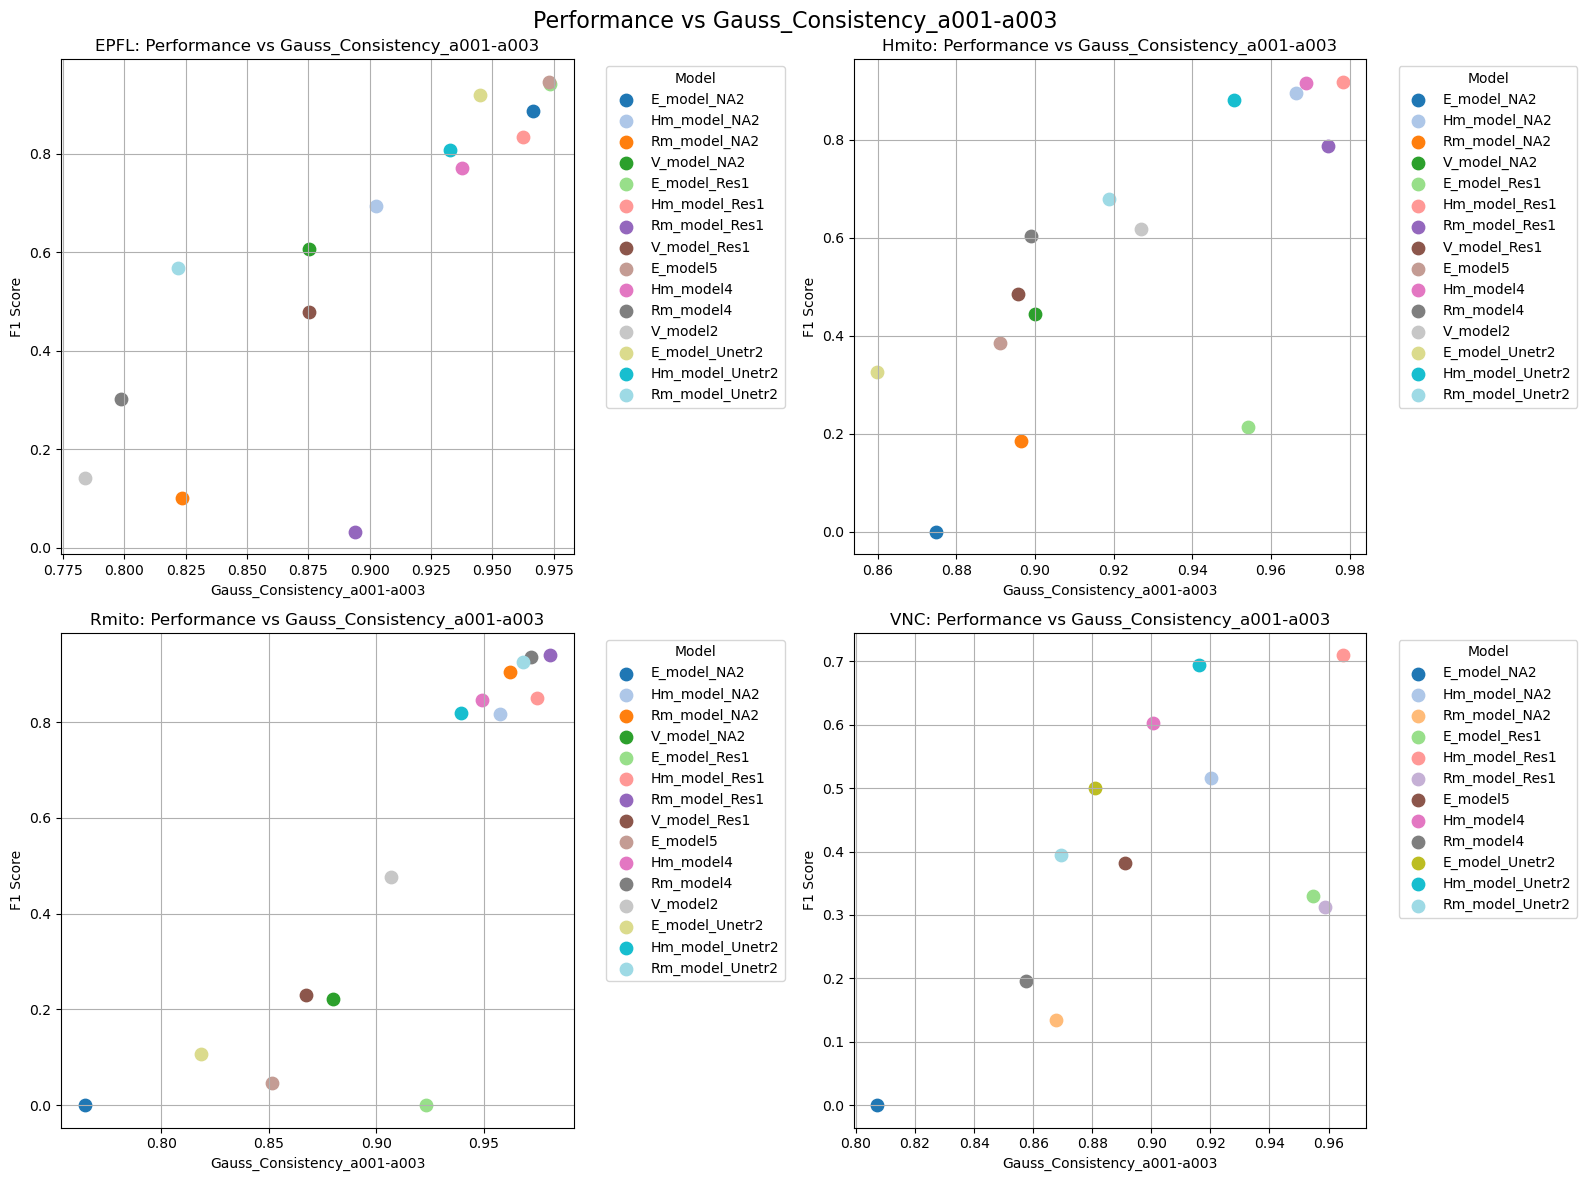

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.82     0.00   0.88        0.00  0.73     0.00
     Hmito    0.75     0.00   0.79        0.00  0.66     0.00
     Rmito    0.87     0.00   0.90        0.00  0.77     0.00
     VNC      0.63     0.03   0.61        0.04  0.45     0.04
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_Gauss_a003-a005__AllLayers_CMB_05f_05b_consistency_scores.json
Processing: Gauss_Consistency_a003-a005
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


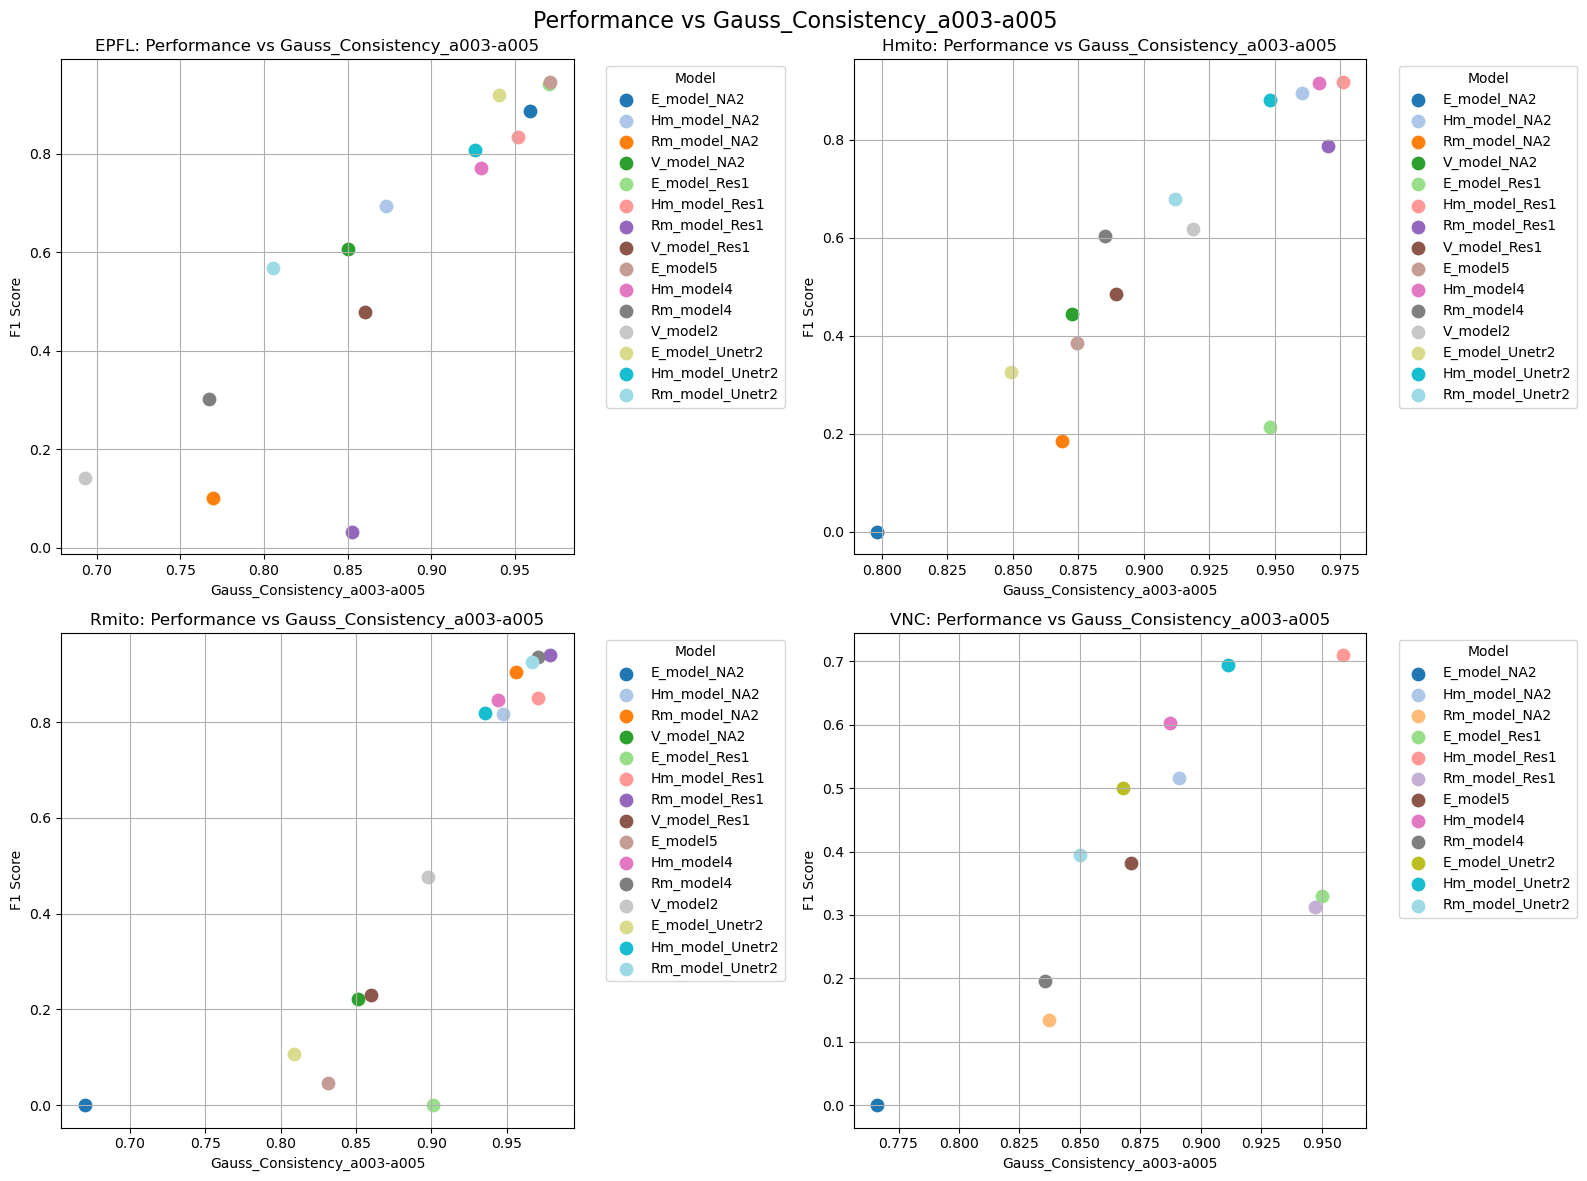

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.86     0.00   0.90        0.00  0.77     0.00
     Hmito    0.82     0.00   0.86        0.00  0.73     0.00
     Rmito    0.84     0.00   0.90        0.00  0.78     0.00
     VNC      0.67     0.02   0.63        0.05  0.52     0.03
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_Gauss_a005-a007__AllLayers_CMB_05f_05b_consistency_scores.json
Processing: Gauss_Consistency_a005-a007
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


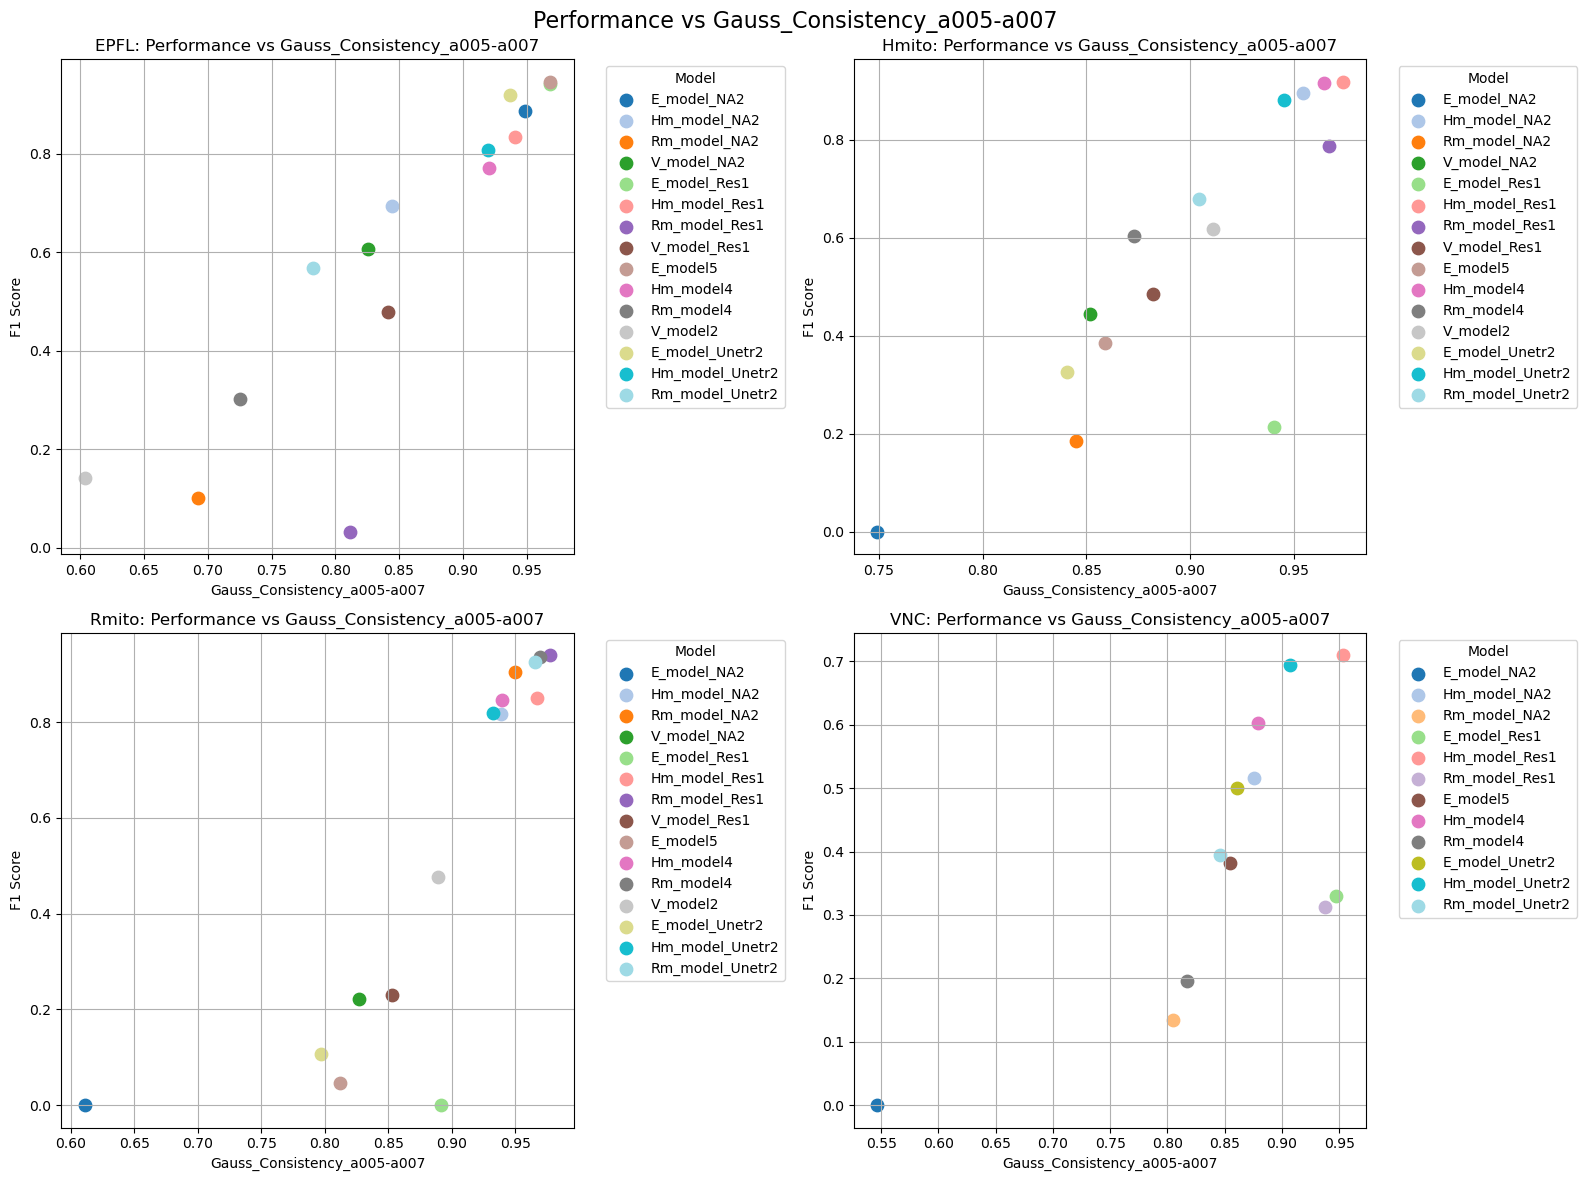

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.88     0.00   0.93        0.00  0.81     0.00
     Hmito    0.83     0.00   0.86        0.00  0.73     0.00
     Rmito    0.82     0.00   0.92        0.00  0.82     0.00
     VNC      0.71     0.01   0.66        0.02  0.61     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_Gauss_a007-a01__AllLayers_CMB_05f_05b_consistency_scores.json
Processing: Gauss_Consistency_a007-a01
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


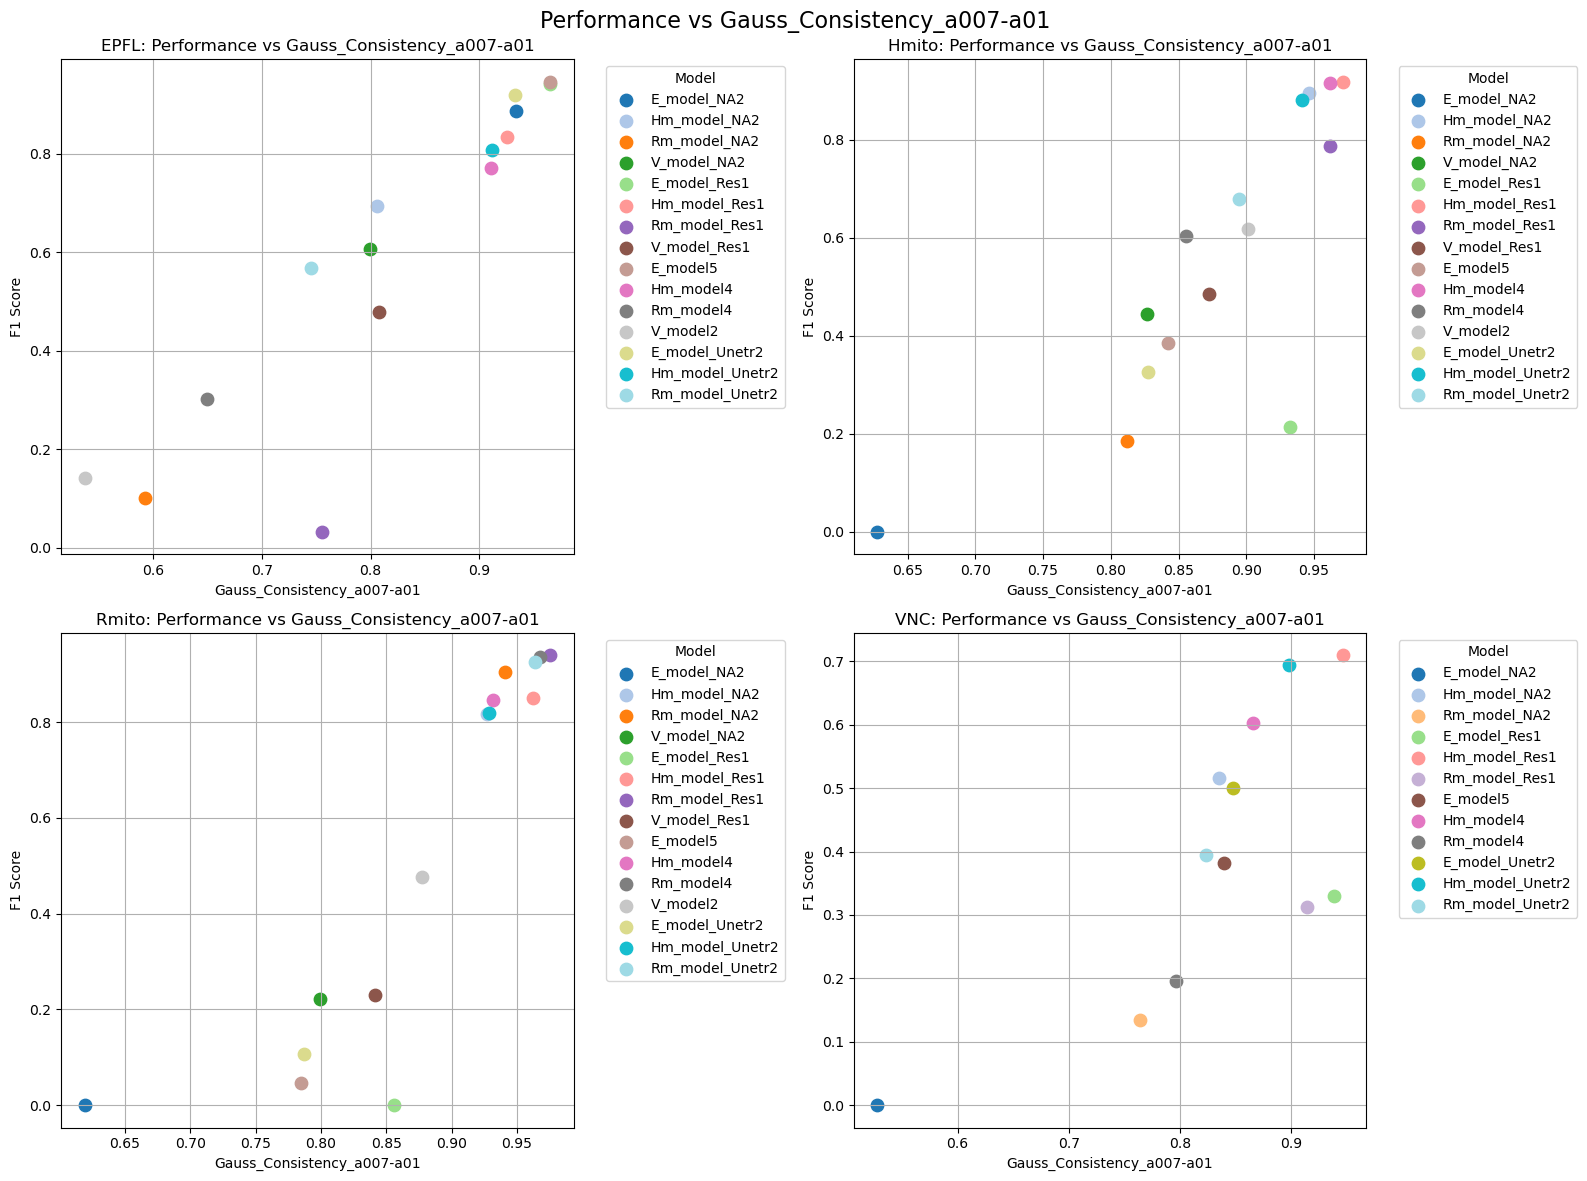

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.90     0.00   0.93        0.00  0.83     0.00
     Hmito    0.82     0.00   0.87        0.00  0.75     0.00
     Rmito    0.88     0.00   0.95        0.00  0.90     0.00
     VNC      0.73     0.01   0.63        0.03  0.55     0.01
Loaded Transfer metric results from: /g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_Gauss_a01-a02__AllLayers_CMB_05f_05b_consistency_scores.json
Processing: Gauss_Consistency_a01-a02
Number of targets: 4
  Target 1: EPFL
  Target 2: Hmito
  Target 3: Rmito
  Target 4: VNC


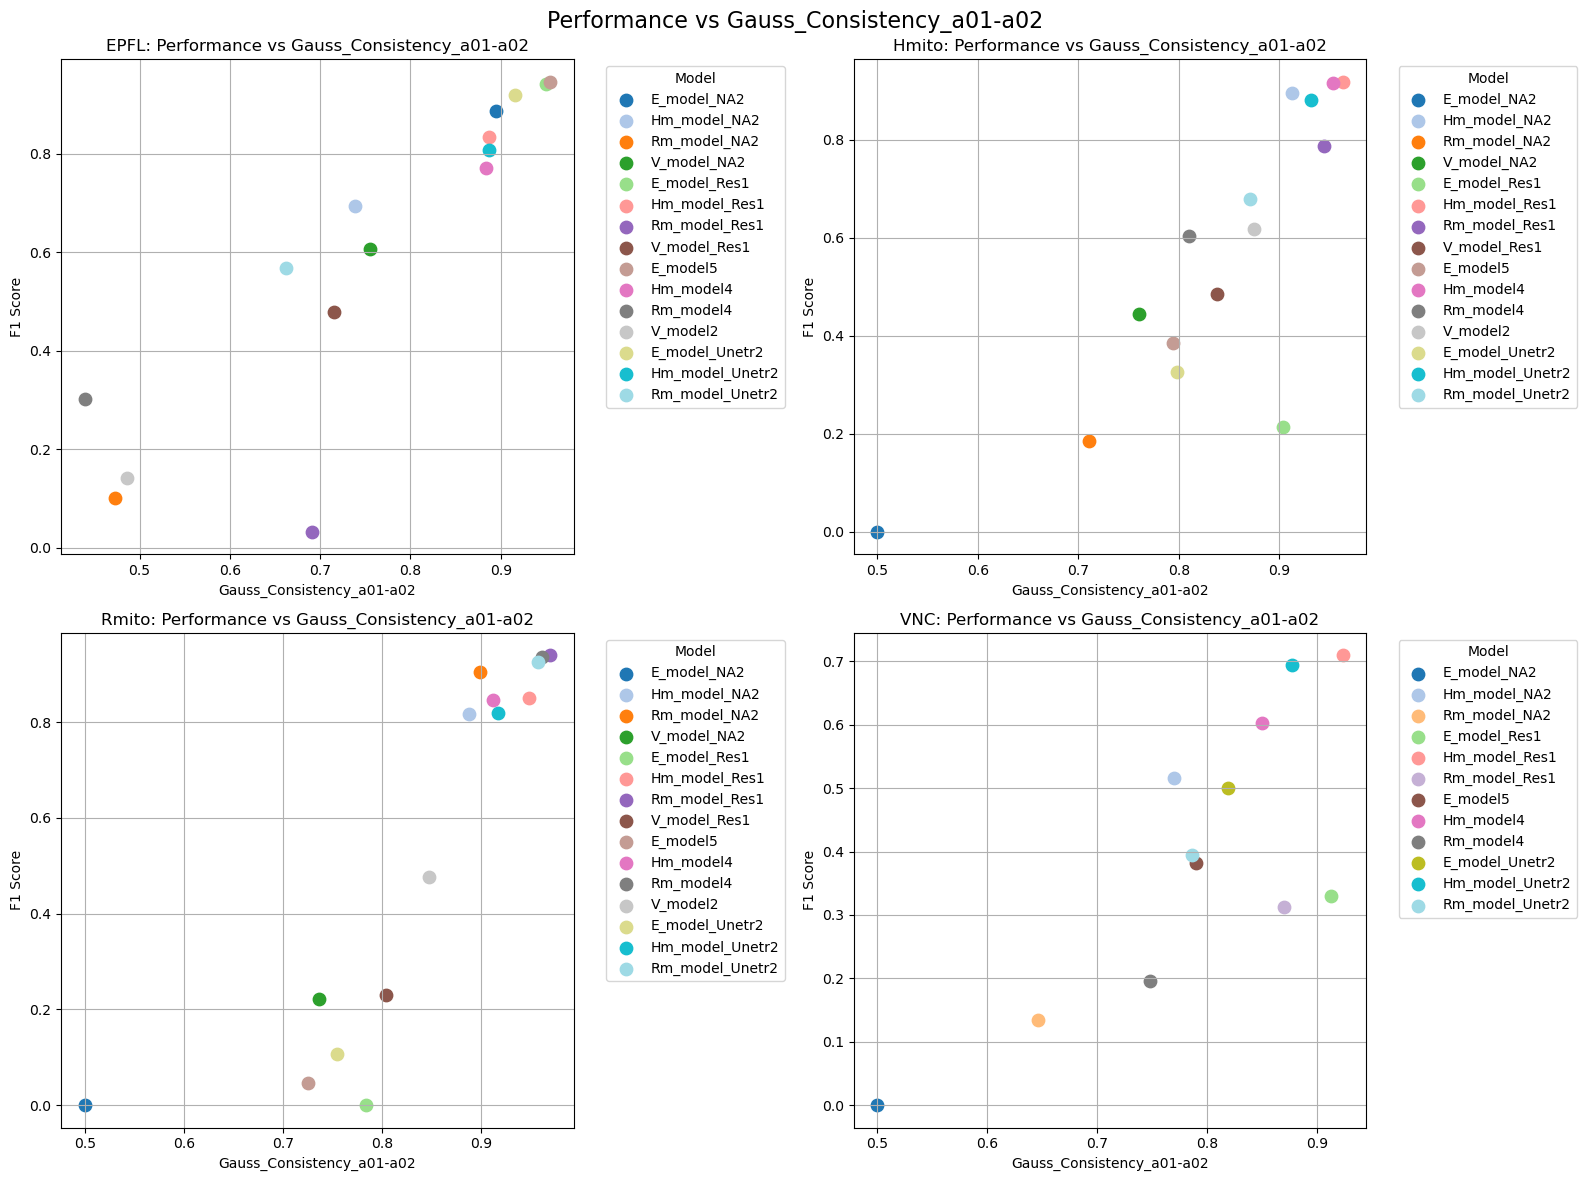

                kt  kt pval  s rho  s rho pval    pr  pr pval
Task targets                                                 
Mito EPFL     0.89      0.0   0.94        0.00  0.85     0.00
     Hmito    0.83      0.0   0.86        0.00  0.71     0.00
     Rmito    0.87      0.0   0.94        0.00  0.84     0.00
     VNC      0.78      0.0   0.66        0.03  0.55     0.02


In [7]:
base_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency"
selected_augmentations = ["a001-a003", "a003-a005", "a005-a007", "a007-a01", "a01-a02"]

for aug in selected_augmentations:
    file_name = f"transfer_Gauss_{aug}__AllLayers_CMB_05f_05b_consistency_scores.json"
    consistency_path = Path(base_path) / file_name
    results = load_transfer_metric_results(consistency_path)
    consistency_scores = results["transfer_scores"]
    targets = list(consistency_scores.keys())
    plot_performance_vs_transfer_metric_multi_target(
        performance_scores=performance_scores,
            transfer_scores=consistency_scores,
            transfer_metric=f"Gauss_Consistency_{aug}",
        )
    KT_scores, SP_scores, PE_scores = to_target_transfer_correlations(
        targets=targets,
        transfer_metric_per_target=consistency_scores,
        performance_per_target=performance_scores,
        )
    correlation_df = correlation_table(KT_scores, SP_scores, PE_scores, targets=targets)
    print(correlation_df)
            
        

# Combined Plot

In [4]:
performance_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/transfer_performance_scores_with_NORM.json"
with open(performance_path, "r") as f:
    performance_scores = json.load(f)["performance_scores"]


In [5]:
consistency_path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/transfer_results/consistency/transfer_GaussSweep_AllLayers_CMB_05f_05b_consistency_scores_with_NORM.json"
with open(consistency_path, "r") as f:
    consistency_scores = json.load(f)["transfer_scores"]

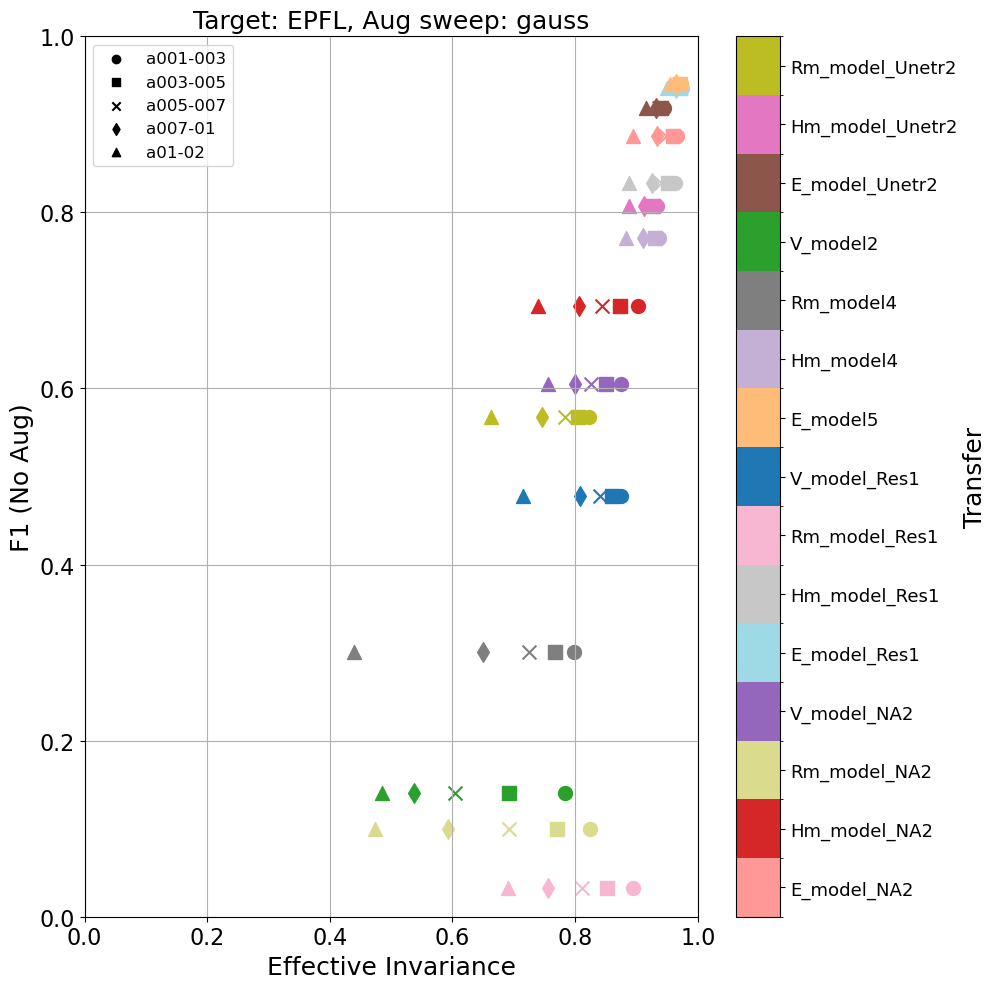

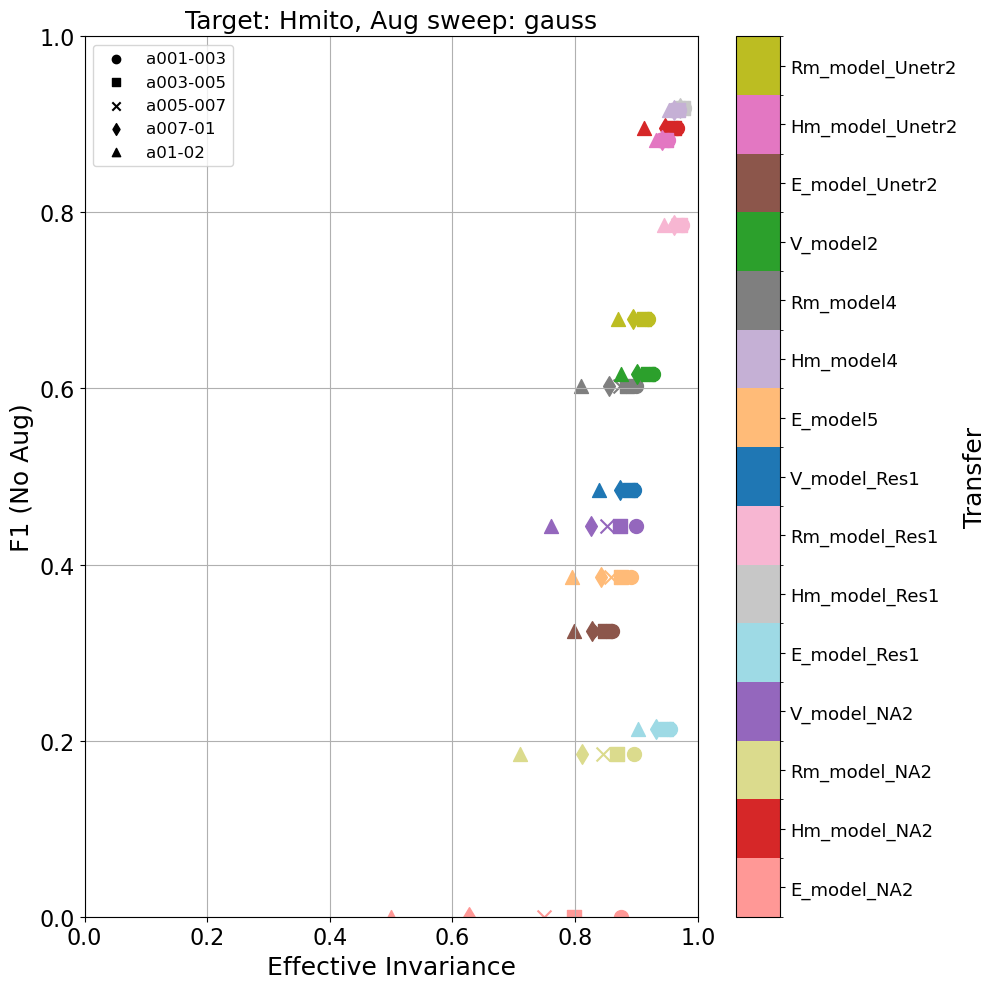

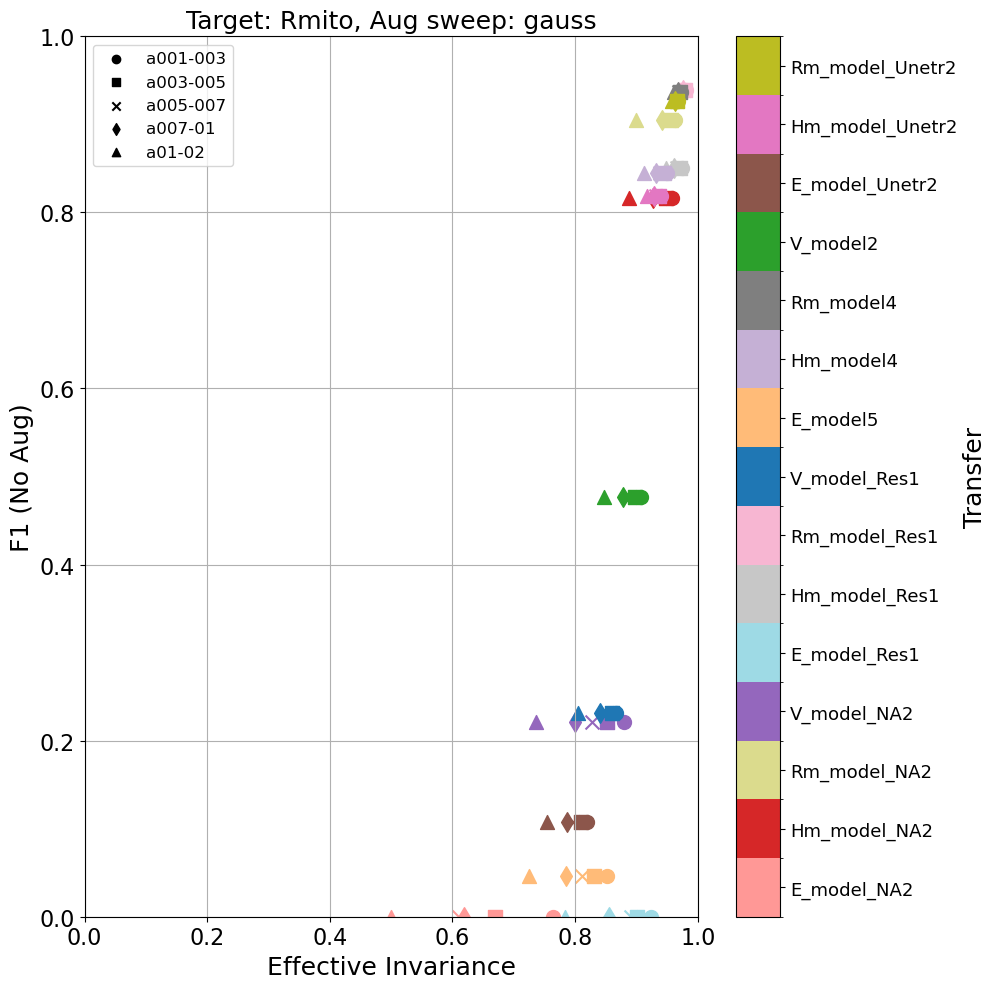

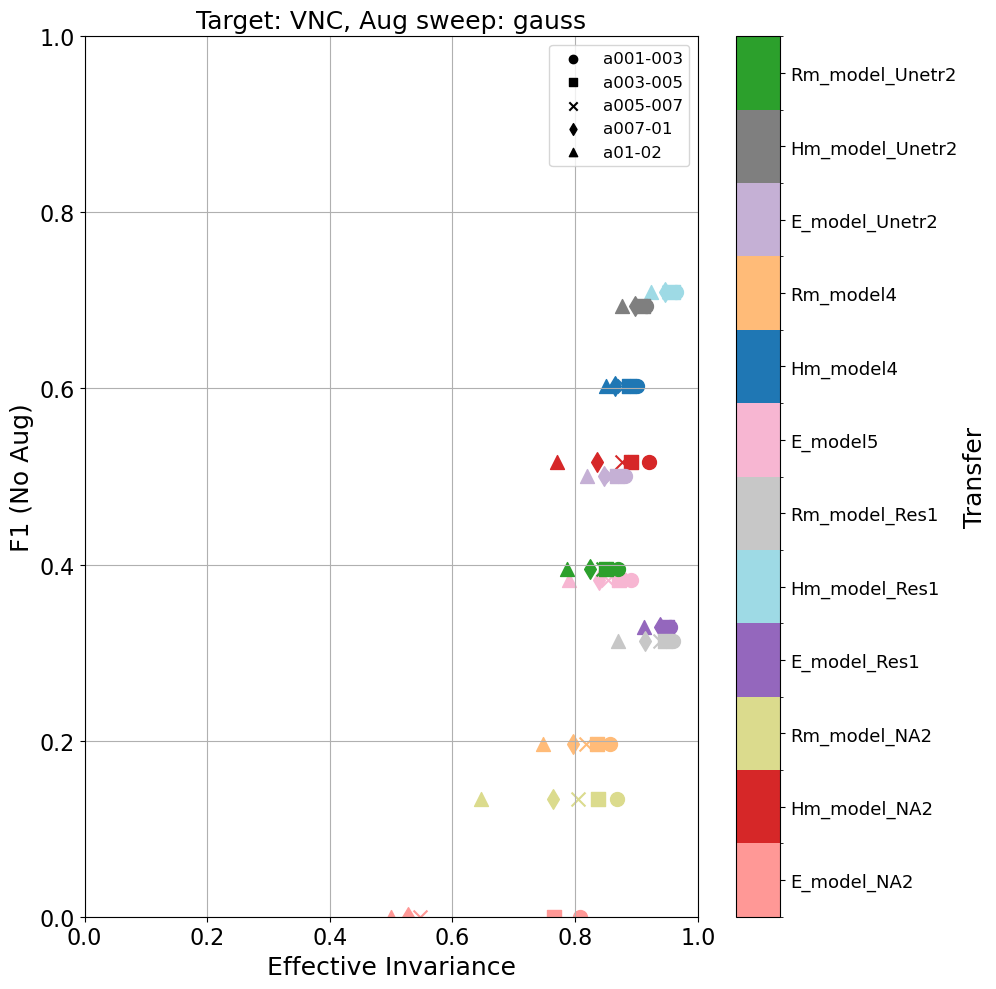

In [6]:
selected_augmentations = {
    "none": [""],
    "gauss": ["a001-003", "a003-005", "a005-007", "a007-01", "a01-02"],
}
per_target_norms: Dict[str, List[None]] = {
    "EPFL": [None],
    "Hmito": [None],
    "Rmito": [None],
    "VNC": [None],
}

for target in consistency_scores.keys():
    plot_alpha_sweep_specific_norm(
        consistency_scores[target],
        performance_scores[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="Effective Invariance",
        invert_consis_metric= False,
        invert_perf_metric=False,
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )